In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [47]:
df0 = pd.read_excel("data/xst.xlsx", sheet_name="A1.1")
df0.set_index("beta", inplace=True)
df1 = pd.read_excel("data/xst.xlsx", sheet_name="A2")
df1.set_index("beta", inplace=True)
df = pd.merge(df0, df1, left_index=True, right_index=True, how="inner", suffixes=("_0", ""))
df["trans"] = df["R"] / df["R_0"]
df["abs"] = 1 - df["trans"]
df

,R_0,R,trans,abs
beta,,,,
4.0,333,144,0.432432,0.567568
4.1,353,184,0.521246,0.478754
4.2,350,170,0.485714,0.514286
4.3,444,170,0.382883,0.617117
4.4,419,178,0.424821,0.575179
...,...,...,...,...
9.6,97,32,0.329897,0.670103
9.7,89,24,0.269663,0.730337
9.8,73,20,0.273973,0.726027


In [48]:
a_NACL = 564.02

beta_rad = np.radians(df.index)
df["lambda_pm"] = a_NACL * np.sin(beta_rad)

df.set_index("lambda_pm", inplace=True)

df[df.index > 60]

,R_0,R,trans,abs
lambda_pm,,,,
60.913797,590,88,0.149153,0.850847
61.892346,773,87,0.112549,0.887451
62.870707,728,77,0.105769,0.894231
63.848877,519,51,0.098266,0.901734
64.826852,383,46,0.120104,0.879896
65.804629,352,42,0.119318,0.880682
66.782206,330,49,0.148485,0.851515
67.759580,368,126,0.342391,0.657609
68.736747,828,448,0.541063,0.458937


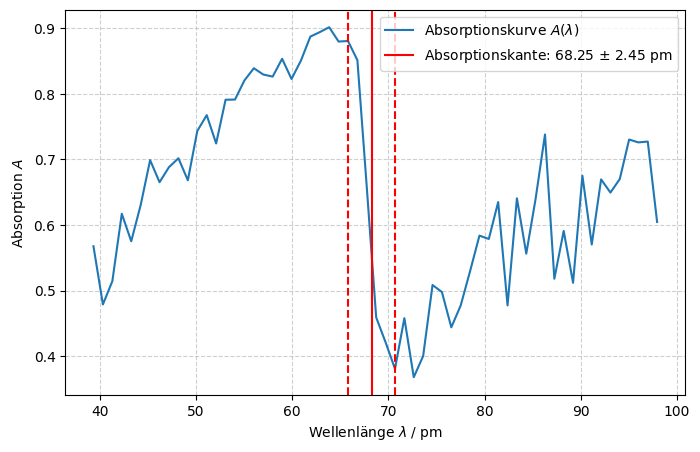

In [60]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df.index, df["abs"], linestyle='-', label='Absorptionskurve $A(\lambda)$')

ax.set_xlabel(r"Wellenlänge $\lambda$ / pm")
ax.set_ylabel(r"Absorption $A$")

ax.grid(True, linestyle='--', alpha=0.6)

kante_low = 65.8
kante_up = 70.7
kante_center = (kante_low + kante_up) / 2
kante_unc = (kante_up - kante_low) / 2

ax.axvline(x=kante_center, color='red', linestyle='-', label=f'Absorptionskante: {kante_center:.2f} $\\pm$ {kante_unc:.2f} pm')
ax.axvline(x=kante_low, color='red', linestyle='--')
ax.axvline(x=kante_up, color='red', linestyle='--')

ax.legend()

plt.show()

In [61]:
from scipy.constants import h, c, e
from uncertainties import ufloat

l_pm = ufloat(kante_center, kante_unc)
l_m = l_pm * 1e-12

print(f"Absorptionskante: {l_pm:.2f} pm")
print(f"Absorptionskante: {l_m:.2f} m")

energy_ev = (h * c) / (l_m * e)
energy_kev = energy_ev / 1000

print(f"Energie: {energy_ev:.2f} eV")
print(f"Energie: {energy_kev:.2f} keV")

Absorptionskante: 68.25+/-2.45 pm
Absorptionskante: 0.00+/-0.00 m
Energie: 18166.18+/-652.12 eV
Energie: 18.17+/-0.65 keV
